<a href="https://colab.research.google.com/github/vignesh-codes/ECE9063-Assignment-1/blob/main/linear-regression-basics-v0.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('train.csv')

# Convert the 'date' column to datetime format
# df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
df['date'] = pd.to_datetime(df['date'])
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

# Extract useful features from the date
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

# Add lag features (e.g., sales from the previous day, week, and 12 months ago)
df['lag_1'] = df['sales'].shift(1)  # Previous day's sales
df['lag_7'] = df['sales'].shift(7)  # Previous week's sales
df['lag_365'] = df['sales'].shift(365)  # Previous year's sales (seasonality)

# Add rolling mean (7-day and 30-day rolling averages)
df['rolling_mean_7'] = df['sales'].rolling(window=7).mean()
df['rolling_mean_30'] = df['sales'].rolling(window=30).mean()

# Drop any rows with missing values (due to lag and rolling operations)
df = df.dropna()

In [2]:
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
Index: 912635 entries, 365 to 912999
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   date             912635 non-null  datetime64[ns]
 1   store            912635 non-null  int64         
 2   item             912635 non-null  int64         
 3   sales            912635 non-null  int64         
 4   day              912635 non-null  int32         
 5   month            912635 non-null  int32         
 6   year             912635 non-null  int32         
 7   lag_1            912635 non-null  float64       
 8   lag_7            912635 non-null  float64       
 9   lag_365          912635 non-null  float64       
 10  rolling_mean_7   912635 non-null  float64       
 11  rolling_mean_30  912635 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int32(3), int64(3)
memory usage: 80.1 MB


,date,store,item,sales,day,month,year,lag_1,lag_7,lag_365,rolling_mean_7,rolling_mean_30
365,2014-01-01,1,1,9,1,1,2014,15.0,6.0,13.0,13.428571,12.433333
366,2014-01-02,1,1,14,2,1,2014,9.0,16.0,11.0,13.142857,12.200000
367,2014-01-03,1,1,11,3,1,2014,14.0,18.0,14.0,12.142857,12.366667
368,2014-01-04,1,1,20,4,1,2014,11.0,17.0,13.0,12.571429,12.600000
369,2014-01-05,1,1,17,5,1,2014,20.0,14.0,10.0,13.000000,12.666667
370,2014-01-06,1,1,14,6,1,2014,17.0,5.0,12.0,14.285714,12.566667
371,2014-01-07,1,1,11,7,1,2014,14.0,15.0,10.0,13.714286,12.366667
372,2014-01-08,1,1,12,8,1,2014,11.0,9.0,9.0,14.142857,12.500000
373,2014-01-09,1,1,17,9,1,2014,12.0,14.0,12.0,14.571429,12.600000
374,2014-01-10,1,1,12,10,1,2014,17.0,11.0,9.0,14.714286,12.766667


In [3]:
# 2. Define the Features and Target
# Features include month, lag features, and rolling averages
X = df[['month', 'lag_1', 'lag_7', 'lag_365', 'rolling_mean_7', 'rolling_mean_30']]
y = df['sales']

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# 3. Train the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Make Predictions
y_pred = model.predict(X_test)

In [5]:
from sklearn.metrics import mean_absolute_error, r2_score

# Evaluate the performance of the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae}')
print(f'R-squared: {r2}')

Mean Absolute Error: 6.717010139029286
R-squared: 0.9056094570867408


,date,store,item,sales,day,month,year,lag_1,lag_7,lag_365,rolling_mean_7,rolling_mean_30
365,2014-01-01,1,1,9,1,1,2014,15.0,6.0,13.0,13.428571,12.433333
366,2014-01-02,1,1,14,2,1,2014,9.0,16.0,11.0,13.142857,12.200000
367,2014-01-03,1,1,11,3,1,2014,14.0,18.0,14.0,12.142857,12.366667
368,2014-01-04,1,1,20,4,1,2014,11.0,17.0,13.0,12.571429,12.600000
369,2014-01-05,1,1,17,5,1,2014,20.0,14.0,10.0,13.000000,12.666667
370,2014-01-06,1,1,14,6,1,2014,17.0,5.0,12.0,14.285714,12.566667
371,2014-01-07,1,1,11,7,1,2014,14.0,15.0,10.0,13.714286,12.366667
372,2014-01-08,1,1,12,8,1,2014,11.0,9.0,9.0,14.142857,12.500000
373,2014-01-09,1,1,17,9,1,2014,12.0,14.0,12.0,14.571429,12.600000
374,2014-01-10,1,1,12,10,1,2014,17.0,11.0,9.0,14.714286,12.766667


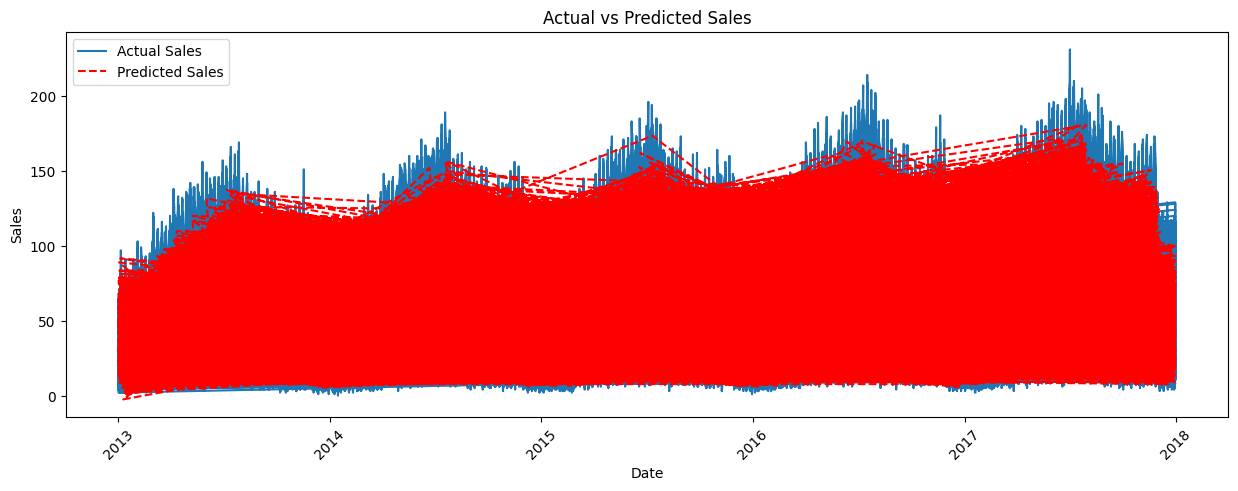

In [11]:
import matplotlib.pyplot as plt

# Extract the corresponding dates for X_test
test_dates = df.loc[X_test.index, 'date']

# Plot the actual vs predicted sales
plt.figure(figsize=(15, 5))
plt.plot(df['date'], df['sales'], label='Actual Sales')
plt.plot(test_dates, y_pred, label='Predicted Sales', color='red', linestyle='--')
plt.title('Actual vs Predicted Sales')
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()